In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(-6.0,6.0,100)
y= np.sqrt(10**2 - x**2)
y=np.hstack([y, -y])
x= np.hstack([x,-x])

In [3]:
x1 = np.linspace(-6.0,6.0,100)
y1= np.sqrt(4**2 - x1**2)
y1=np.hstack([y1, -y1])
x1= np.hstack([x1,-x1])

C:\Users\TAHERALI\AppData\Local\Temp\ipykernel_14732\156944397.py:2: RuntimeWarning: invalid value encountered in sqrt
  y1= np.sqrt(4**2 - x1**2)


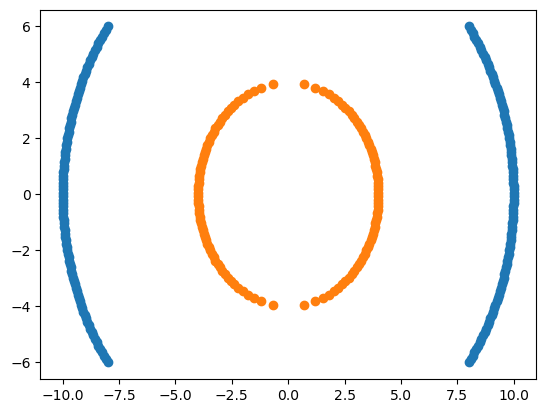

In [4]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [5]:
df1 =pd.DataFrame(np.vstack([y,x]).T,columns=['x1','x2'])
df1['y']=0
df3= pd.DataFrame(np.vstack([y1,x1]).T,columns=['x1','x2'])
df3['y']=1

In [6]:
df = pd.concat([df1,df3],ignore_index = True)

In [7]:
df

,x1,x2,y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0
...,...,...,...
395,NaN,-5.515152,1
396,NaN,-5.636364,1
397,NaN,-5.757576,1
398,NaN,-5.878788,1


In [8]:
df1 = df.copy()

In [9]:
df1 = df1.dropna()

In [10]:
df1["x1sq"] = df1['x1']**2
df1["x2sq"] = df1['x2']**2
df1["x1x2"] = df1["x1"]*df1['x2']
df1.head()

,x1,x2,y,x1sq,x2sq,x1x2
0,8.000000,-6.000000,0,64.000000,36.000000,-48.000000
1,8.089490,-5.878788,0,65.439853,34.560147,-47.556397
2,8.176205,-5.757576,0,66.850321,33.149679,-47.075117
3,8.260230,-5.636364,0,68.231405,31.768595,-46.557662
4,8.341649,-5.515152,0,69.583104,30.416896,-46.005457


In [11]:
df1 = df1.dropna()

In [12]:
x = df1[['x1sq','x2sq','x1x2']]
y = df1['y']

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=1)

In [14]:
x_train

,x1sq,x2sq,x1x2
365,12.470156,3.529844,6.634584
17,84.481175,15.518825,-36.208404
267,11.500459,4.499541,7.193524
235,12.910927,3.089073,-6.315282
88,78.222222,21.777778,41.273553
...,...,...,...
220,3.213958,12.786042,-6.410445
272,8.561983,7.438017,7.980236
72,92.561983,7.438017,26.238856
252,15.908173,0.091827,1.208638


In [15]:
import plotly.express as px

In [16]:
fig =px.scatter_3d(df1, x= 'x1sq',y= 'x2sq',z = 'x1x2',color='y')
fig.show()

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = 'linear') #why linear>> we have created polynomial
cls.fit(x_train, y_train)
y_pred = cls.predict(x_test)
accuracy_score(y_test, y_pred)

1.0

In [18]:
#till now manually  now we ise svc kernel
df = df.dropna()

In [19]:
x = df[["x1","x2"]]
y = df['y']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=1)

In [20]:
x_train

,x1,x2
365,-3.531311,-1.878788
17,9.191364,-3.939394
267,3.391233,2.121212
235,3.593178,-1.757576
88,8.844333,4.666667
...,...,...
220,1.792751,-3.575758
272,2.926087,2.727273
72,9.620914,2.727273
252,3.988505,0.303030


In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = 'poly') #why linear>> we have created polynomial
cls.fit(x_train, y_train)
y_pred = cls.predict(x_test)
accuracy_score(y_test, y_pred)

0.62

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = 'rbf') #why linear>> we have created polynomial
cls.fit(x_train, y_train)
y_pred = cls.predict(x_test)
accuracy_score(y_test, y_pred)

1.0

In [23]:
#sigmoid kernel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = 'sigmoid') #why linear>> we have created polynomial
cls.fit(x_train, y_train)
y_pred = cls.predict(x_test)
accuracy_score(y_test, y_pred)

0.65

In [24]:
#hyer parameter tuning 
#grid search
from sklearn.model_selection import GridSearchCV
params = {'C':[1,2,3,10,50,100],
          'gamma':[1,0.1,0.2,0.003,0.001],
          'kernel':['linear']}

In [25]:
grid =GridSearchCV(SVC(),param_grid=params, cv =5,verbose=True)

In [26]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 2, 3, 10, 50, 100],
                         'gamma': [1, 0.1, 0.2, 0.003, 0.001],
                         'kernel': ['linear']},
             verbose=True)

In [27]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'linear'}

In [28]:
grid.best_score_

np.float64(0.5948196114708603)

In [29]:
y_pred= grid.predict(x_test)

In [30]:
from sklearn.metrics import confusion_matrix,classification_report

In [31]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[62  0]
 [38  0]]
0.62
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        62
           1       0.00      0.00      0.00        38

    accuracy                           0.62       100
   macro avg       0.31      0.50      0.38       100
weighted avg       0.38      0.62      0.47       100



c:\Users\TAHERALI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\TAHERALI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\TAHERALI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [33]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [34]:
data = load_iris()

In [36]:
x,y = load_iris(return_X_y= True)

In [38]:
xtrain,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=1)

In [39]:
from sklearn.naive_bayes import GaussianNB

In [40]:
model = GaussianNB()

In [41]:
model.fit(xtrain,y_train)

GaussianNB()

In [42]:
y_pred = model.predict(x_test)

In [44]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[14  0  0]
 [ 0 16  2]
 [ 0  1 12]]
0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.89      0.91        18
           2       0.86      0.92      0.89        13

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45

